## FPL 2024-25 Forward Data Analysis

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
# Read csv
df = pd.read_csv(r"D:\PythonFiles\FPL_2024_25\FPL_2024-25\Data\Datasets\forwards_complete.csv")

In [ ]:
# Many columns, so checking what columns there are
df.columns.to_list()

In [134]:
# Checking random 10 samples
df.sample(10)

,can_transact,can_select,chance_of_playing_next_round,chance_of_playing_this_round,code,cost_change_event,cost_change_event_fall,cost_change_start,cost_change_start_fall,dreamteam_count,...,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
73,True,False,100.0,100.0,490145,0,0,-1,1,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
20,True,False,0.0,0.0,66749,0,0,-2,2,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
41,True,False,0.0,0.0,94926,0,0,0,0,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
67,True,False,0.0,0.0,476888,0,0,0,0,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
30,True,False,0.0,0.0,115382,0,0,-1,1,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
15,True,False,0.0,0.0,574402,0,0,0,0,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
24,True,False,100.0,100.0,205533,0,0,-1,1,1,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
31,True,False,100.0,100.0,440993,0,0,-3,3,3,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
27,True,False,100.0,100.0,440323,0,0,-2,2,0,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87
64,True,False,100.0,100.0,60689,0,0,12,-12,5,...,Forward,FWD,3,NaN,NaN,1,3,False,[],87


In [135]:
cols_req = ['id','web_name','name','minutes','goals_scored','bps','starts','own_goals','penalties_missed', 'yellow_cards','expected_goals',
 'red_cards','assists','expected_assists',
 'expected_goal_involvements','total_points']
df_refined = df[cols_req]

In [136]:
df_refined = df_refined.assign(
    net_xG = df_refined['goals_scored'] - df_refined['expected_goals'],
    net_xA = df_refined['assists'] - df_refined['expected_assists'],
    GA = df_refined['goals_scored'] + df_refined['assists']
)

### xG Overperformers and Underperformers
#### For Forwards who played atleast 300 minutes and atleast 1 goal

In [137]:
df_refined = df_refined[(df_refined['minutes'] > 300) & (df_refined['goals_scored'] > 0)]
df_refined[['web_name','name','goals_scored','expected_goals']].sort_values(by='goals_scored',ascending=False).head(5)

,web_name,name,goals_scored,expected_goals
57,Isak,Newcastle,23,20.33
49,Haaland,Man City,22,21.90
64,Wood,Nott'm Forest,20,13.42
12,Wissa,Brentford,18,18.58
4,Watkins,Aston Villa,16,15.12


In [138]:
df_refined['net_xG'] = df_refined['goals_scored'] - df_refined['expected_goals']
df_refined[['web_name','name','goals_scored','expected_goals','net_xG']].sort_values(by='net_xG',ascending=False).head(5)

,web_name,name,goals_scored,expected_goals,net_xG
64,Wood,Nott'm Forest,20,13.42,6.58
81,Cunha,Wolves,15,8.73,6.27
85,Strand Larsen,Wolves,14,10.14,3.86
47,Gakpo,Liverpool,10,7.12,2.88
31,Ndiaye,Everton,9,6.23,2.77


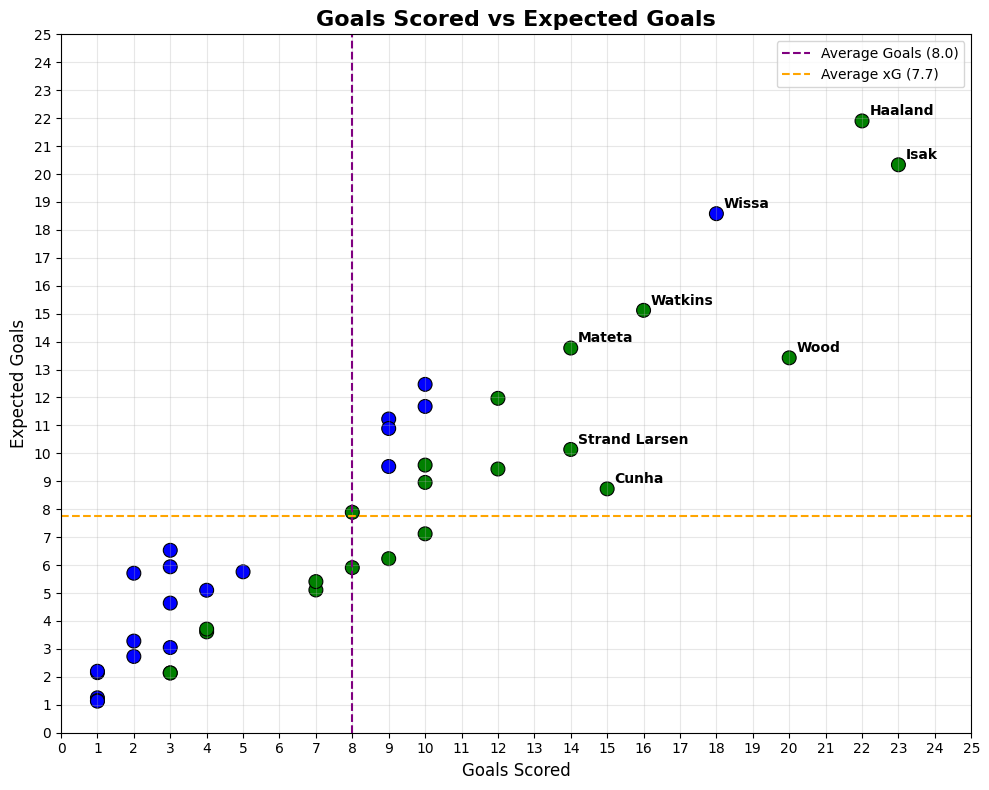

In [139]:
plt.figure(figsize=(10, 8))

# Scatter plot with color based on net_xG
sns.scatterplot(
    data=df_refined,
    x='goals_scored',
    y='expected_goals',
    hue=df_refined['net_xG'] > 0,
    palette={True: 'green', False: 'blue'},
    s=100,
    edgecolor='black',
    legend=False
)


# Calculate averages
avg_goals = df_refined['goals_scored'].mean()
avg_xg = df_refined['expected_goals'].mean()

# Add average lines
plt.axvline(avg_goals, color='purple', linestyle='--', linewidth=1.5, label=f'Average Goals ({avg_goals:.1f})')
plt.axhline(avg_xg, color='orange', linestyle='--', linewidth=1.5, label=f'Average xG ({avg_xg:.1f})')

# Title and axis labels
plt.title('Goals Scored vs Expected Goals', fontsize=16, fontweight='bold')
plt.xlabel('Goals Scored', fontsize=12)
plt.ylabel('Expected Goals', fontsize=12)

# Grid, limits, and ticks
plt.grid(alpha=0.3)
plt.xlim(0, 25)
plt.ylim(0, 25)
plt.xticks(np.arange(0, 26, 1))
plt.yticks(np.arange(0, 26, 1))

# Annotate top 8 goal scorers
top8 = df_refined.nlargest(8, 'goals_scored')
for i, row in top8.iterrows():
    plt.text(
        row['goals_scored'] + 0.2, 
        row['expected_goals'] + 0.2, 
        row['web_name'], 
        fontsize=10, 
        fontweight='bold'
    )

plt.legend()
plt.tight_layout()
plt.show()

- Above Red Line, Blue Dots represents xG under rperformers
- Below Red Line, Green Dots represents xG over performers

In [140]:
# Top xG overperformers
df_refined[['web_name','name','goals_scored','expected_goals','net_xG']].sort_values(by='net_xG',ascending=False).head(5)

,web_name,name,goals_scored,expected_goals,net_xG
64,Wood,Nott'm Forest,20,13.42,6.58
81,Cunha,Wolves,15,8.73,6.27
85,Strand Larsen,Wolves,14,10.14,3.86
47,Gakpo,Liverpool,10,7.12,2.88
31,Ndiaye,Everton,9,6.23,2.77


In [141]:
# Top xG underperformers
df_refined[['web_name','name','goals_scored','expected_goals','net_xG']].sort_values(by='net_xG',ascending=True).head(5)

,web_name,name,goals_scored,expected_goals,net_xG
65,Archer,Southampton,2,5.71,-3.71
29,Calvert-Lewin,Everton,3,6.53,-3.53
24,Nketiah,Crystal Palace,3,5.94,-2.94
7,Evanilson,Bournemouth,10,12.47,-2.47
45,Vardy,Leicester,9,11.23,-2.23


In [142]:
# Neither underformed or overperformed - Ideal
df_refined.loc[
    df_refined['net_xG'].abs().nsmallest(5).index,
    ['web_name','name', 'goals_scored', 'expected_goals', 'net_xG']
]

,web_name,name,goals_scored,expected_goals,net_xG
35,Raúl,Fulham,12,11.97,0.03
0,G.Jesus,Arsenal,3,3.05,-0.05
49,Haaland,Man City,22,21.90,0.10
28,Beto,Everton,8,7.89,0.11
76,Ferguson,West Ham,1,1.13,-0.13


### xA and (FPL )Assists

In [143]:
df_refined[['web_name','name','assists','expected_assists']].sort_values(by='expected_assists',ascending=False).head(10)

,web_name,name,assists,expected_assists
81,Cunha,Wolves,7,5.29
47,Gakpo,Liverpool,5,3.76
57,Isak,Newcastle,6,3.59
14,João Pedro,Brighton,6,3.10
45,Vardy,Leicester,5,2.55
25,Mateta,Crystal Palace,2,2.28
12,Wissa,Brentford,6,2.20
35,Raúl,Fulham,3,2.07
4,Watkins,Aston Villa,8,2.07
49,Haaland,Man City,3,2.04


In [144]:
df_refined[['web_name','name','goals_scored','assists','GA','expected_goals','expected_assists','expected_goal_involvements']].sort_values(by='GA',ascending=False).head(10)

,web_name,name,goals_scored,assists,GA,expected_goals,expected_assists,expected_goal_involvements
57,Isak,Newcastle,23,6,29,20.33,3.59,23.92
49,Haaland,Man City,22,3,25,21.90,2.04,23.94
4,Watkins,Aston Villa,16,8,24,15.12,2.07,17.19
12,Wissa,Brentford,18,6,24,18.58,2.20,20.77
64,Wood,Nott'm Forest,20,3,23,13.42,1.59,15.01
81,Cunha,Wolves,15,7,22,8.73,5.29,14.02
85,Strand Larsen,Wolves,14,4,18,10.14,1.00,11.14
22,N.Jackson,Chelsea,10,6,16,11.68,1.90,13.58
14,João Pedro,Brighton,10,6,16,8.96,3.10,12.06
25,Mateta,Crystal Palace,14,2,16,13.77,2.28,16.05


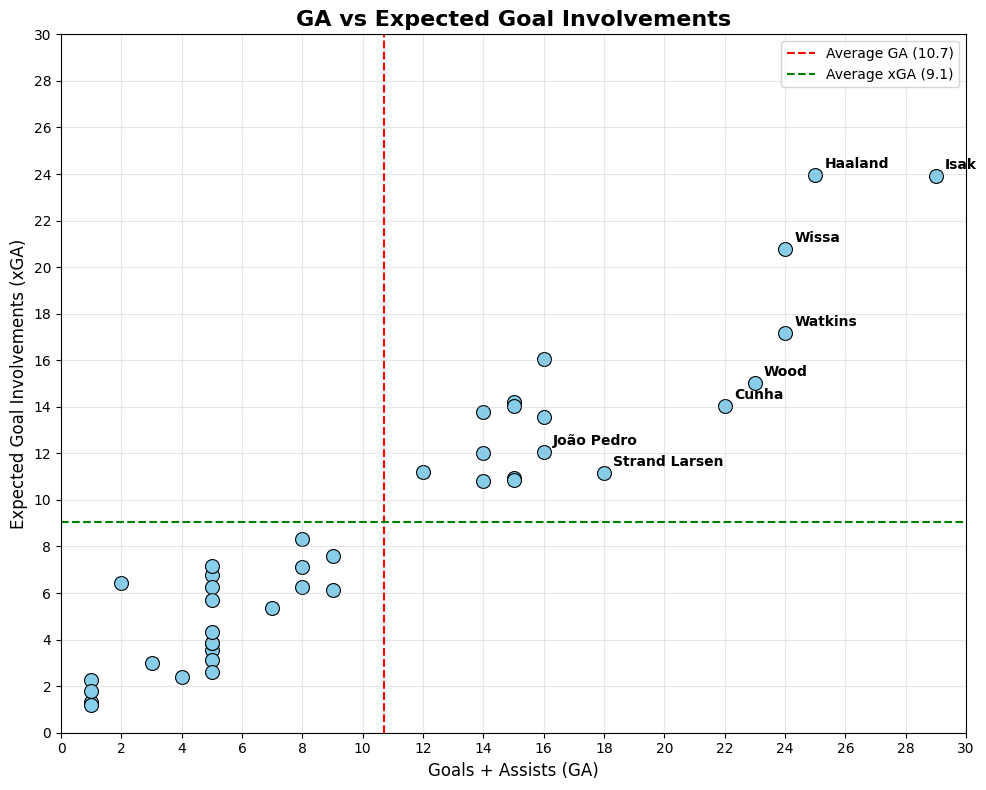

In [145]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_refined,
    x='GA',
    y='expected_goal_involvements',
    s=100,          # size of points
    color='skyblue',
    edgecolor='black'
)

# Calculate averages
avg_ga = df_refined['GA'].mean()
avg_xga = df_refined['expected_goal_involvements'].mean()

# Add average lines
plt.axvline(avg_ga, color='red', linestyle='--', linewidth=1.5, label=f'Average GA ({avg_ga:.1f})')
plt.axhline(avg_xga, color='green', linestyle='--', linewidth=1.5, label=f'Average xGA ({avg_xga:.1f})')

# Title and axis labels
plt.title('GA vs Expected Goal Involvements', fontsize=16, fontweight='bold')
plt.xlabel('Goals + Assists (GA)', fontsize=12)
plt.ylabel('Expected Goal Involvements (xGA)', fontsize=12)

# Grid, limits, and ticks
plt.grid(alpha=0.3)
plt.xlim(0, 30)
plt.ylim(0, 30)
plt.xticks(np.arange(0, 31, 2))
plt.yticks(np.arange(0, 31, 2))

# Annotate top 8 GA with player names
top8 = df_refined.nlargest(8, 'GA')
for i, row in top8.iterrows():
    plt.text(
        row['GA'] + 0.3, 
        row['expected_goal_involvements'] + 0.3, 
        row['web_name'], 
        fontsize=10, 
        fontweight='bold'
    )

plt.legend()
plt.tight_layout()
plt.show()